# Content-based Logistic Regression

This notebook is the LR baseline for the Expedia hotel ranking competition. We pick up after the training data has already been preprocessed (`training_X_full.csv` + `training_y_full.csv`).

## 0. Config and imports

In [1]:
from pathlib import Path
import gc

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def _data_dir() -> Path:
    here = Path.cwd()
    for candidate in (here, here / "Assignment_2"):
        if (candidate / "training_X_full.csv").is_file():
            return candidate
    return here

DATA_DIR = _data_dir()
print("DATA_DIR =", DATA_DIR)

TRAIN_RAW = DATA_DIR / "training_set_VU_DM.csv"
TRAIN_X = DATA_DIR / "training_X_full.csv"
TRAIN_Y = DATA_DIR / "training_y_full.csv"
TEST_RAW = DATA_DIR / "test_set_VU_DM.csv"
TEST_X = DATA_DIR / "test_X_full.csv"
SUBMISSION = DATA_DIR / "submission_lr.csv"
SUBMISSION_IPS = DATA_DIR / "submission_lr_debiased.csv"

FILL_NANS = True
CHUNK = 500_000

for label, path in [
    ("training raw (for IPS)    ", TRAIN_RAW),
    ("training X (from teammate)", TRAIN_X),
    ("training y (from teammate)", TRAIN_Y),
    ("test raw                  ", TEST_RAW),
    ("test X (we will build it) ", TEST_X),
]:
    print(f"  {label}: {'exists' if path.is_file() else 'MISSING'} -- {path.name}")

DATA_DIR = /Users/yaqiduan/Desktop/DataMining/DataMiningTechniques_A1/Assignment_2/content_based_lr
  training raw (for IPS)    : exists -- training_set_VU_DM.csv
  training X (from teammate): exists -- training_X_full.csv
  training y (from teammate): exists -- training_y_full.csv
  test raw                  : exists -- test_set_VU_DM.csv
  test X (we will build it) : exists -- test_X_full.csv


## 1. Feature-engineering functions

These are mainly copied from the preprocessing notebook so we know train and test get exactly the same transformations.

In [2]:
COMP_RATE_COLS = [f"comp{i}_rate" for i in range(1, 9)]
COMP_INV_COLS = [f"comp{i}_inv" for i in range(1, 9)]
COMP_DIFF_COLS = [f"comp{i}_rate_percent_diff" for i in range(1, 9)]


def downcast_numeric(df: pd.DataFrame) -> pd.DataFrame:
    for c in df.columns:
        if c == "date_time":
            continue
        if df[c].dtype == np.float64:
            df[c] = df[c].astype(np.float32)
        elif df[c].dtype == np.int64:
            lo, hi = df[c].min(), df[c].max()
            if hi <= 127 and lo >= -128:
                df[c] = df[c].astype(np.int8)
            else:
                df[c] = df[c].astype(np.int32)
    return df


def preprocess_base(df: pd.DataFrame) -> pd.DataFrame:
    df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")
    df["srch_hour"] = df["date_time"].dt.hour.astype("float32")
    df["srch_dow"] = df["date_time"].dt.dayofweek.astype("float32")
    df["srch_month"] = df["date_time"].dt.month.astype("float32")
    if FILL_NANS:
        for c in COMP_RATE_COLS + COMP_INV_COLS:
            df[c] = df[c].fillna(-999)
        for c in COMP_DIFF_COLS:
            df[c] = df[c].fillna(0.0)
        df["visitor_hist_starrating"] = df["visitor_hist_starrating"].fillna(-1.0)
        df["visitor_hist_adr_usd"] = df["visitor_hist_adr_usd"].fillna(-1.0)
        for c in ["prop_review_score", "prop_location_score2",
                  "orig_destination_distance", "srch_query_affinity_score"]:
            df[c] = df[c].fillna(df[c].median())
    return df


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df
    out["log_price_usd"] = np.log1p(out["price_usd"].clip(lower=0).to_numpy(dtype=np.float32)).astype("float32")
    out["price_minus_hist_log"] = (out["log_price_usd"] - out["prop_log_historical_price"].astype("float32")).astype("float32")

    vhist = out["visitor_hist_starrating"].to_numpy(dtype=np.float32)
    star = out["prop_starrating"].to_numpy(dtype=np.float32)
    star_m = star - np.where((vhist < 0) | np.isnan(vhist), np.nan, vhist)
    if FILL_NANS:
        star_m = np.nan_to_num(star_m, nan=0.0)
    out["star_minus_visitor_hist"] = star_m.astype("float32")

    out["visitor_country_eq_prop_country"] = (
        out["visitor_location_country_id"] == out["prop_country_id"]
    ).astype(np.int8)

    los = out["srch_length_of_stay"].replace(0, np.nan)
    out["price_per_night"] = (out["price_usd"] / los).astype("float32")
    if FILL_NANS:
        out["price_per_night"] = out["price_per_night"].fillna(out["price_usd"].astype("float32"))

    g = out.groupby("srch_id", sort=False)
    med_price = g["price_usd"].transform("median")
    med_safe = med_price.replace(0, np.nan)
    out["price_ratio_to_srch_median"] = (out["price_usd"] / med_safe).astype("float32")
    out["price_rank_pct_in_srch"] = g["price_usd"].rank(pct=True).astype("float32")
    out["star_rank_pct_in_srch"] = g["prop_starrating"].rank(pct=True).astype("float32")
    out["review_rank_pct_in_srch"] = g["prop_review_score"].rank(pct=True).astype("float32")
    out["dist_rank_pct_in_srch"] = g["orig_destination_distance"].rank(pct=True, ascending=True).astype("float32")
    out["score1_rank_pct_in_srch"] = g["prop_location_score1"].rank(pct=True).astype("float32")
    out["n_props_in_srch"] = g["prop_id"].transform("size").astype("int32")

    rates = out[COMP_RATE_COLS]
    out["comp_n_better_rate"] = (rates == 1).sum(axis=1).astype(np.int8)
    out["comp_n_worse_rate"] = (rates == -1).sum(axis=1).astype(np.int8)
    if FILL_NANS:
        out["comp_n_rate_observed"] = rates.ne(-999).sum(axis=1).astype(np.int8)
    else:
        out["comp_n_rate_observed"] = rates.notna().sum(axis=1).astype(np.int8)
    diffs = out[COMP_DIFF_COLS]
    out["comp_mean_abs_pct_diff"] = diffs.abs().mean(axis=1, skipna=True).astype("float32")

    for c in ["price_ratio_to_srch_median", "price_minus_hist_log"]:
        out[c] = out[c].replace([np.inf, -np.inf], np.nan).astype("float32")
        if FILL_NANS:
            out[c] = out[c].fillna(0).astype("float32")
    return out


def write_csv_chunked(df: pd.DataFrame, path: Path, chunk: int = CHUNK) -> None:
    for i, start in enumerate(range(0, len(df), chunk)):
        df.iloc[start:start+chunk].to_csv(
            path, mode="w" if i == 0 else "a",
            header=(i == 0), index=False,
        )

## Section A: preprocess the test set

The test set has the same raw columns as training but no labels. We apply the same FE pipeline, then keep only the columns that survived feature selection on training (variance + correlation pruning) so train and test end up with identical feature schemas.

In [3]:
if TEST_X.is_file():
    print(f"{TEST_X.name} already exists, skipping. (Delete the file to regenerate.)")
elif not TEST_RAW.is_file():
    raise FileNotFoundError(
        f"{TEST_RAW} not found. Download test_set_VU_DM.csv from Kaggle and place it in {DATA_DIR}."
    )
else:
    print(f"Loading {TEST_RAW.name} ...")

test_X_full.csv already exists, skipping. (Delete the file to regenerate.)


In [4]:
%%time
if not TEST_X.is_file():
    test = pd.read_csv(TEST_RAW)
    print("raw test shape:", test.shape)
    downcast_numeric(test)
    preprocess_base(test)
    test.drop(columns=["date_time"], inplace=True, errors="ignore")
    add_engineered_features(test)
    print("after FE:", test.shape)
    gc.collect()
else:
    test = None
    print("test_X_full.csv already exists, skipping FE.")

test_X_full.csv already exists, skipping FE.
CPU times: user 193 μs, sys: 263 μs, total: 456 μs
Wall time: 286 μs


In [5]:
if not TEST_X.is_file():
    train_x_cols = pd.read_csv(TRAIN_X, nrows=0).columns.tolist()
    feature_cols_from_train = [c for c in train_x_cols if c not in ("srch_id", "split")]
    missing = [c for c in feature_cols_from_train if c not in test.columns]
    if missing:
        raise RuntimeError(f"Missing columns in test after FE: {missing}")
    out_cols = ["srch_id", "prop_id"] + feature_cols_from_train
    test_out = test[out_cols].copy()
    write_csv_chunked(test_out, TEST_X)
    print(f"Wrote {TEST_X} — {test_out.shape}")
    del test, test_out
    gc.collect()
else:
    print("Test preprocessing was skipped; test_X_full.csv was reused.")

Test preprocessing was skipped; test_X_full.csv was reused.


## Section B: add interaction features, train LR

We add eight hand-picked interaction features (products and squared deviations) to give the linear model a chance to capture those patterns.

Two separate LRs are trained: one predicting `booking_bool`, one predicting `click_bool`. The combined ranking score is `4 * P(book) + P(click)`, which lines up with the NDCG relevance grading (booked = 5, clicked-only = 1, neither = 0).

In [6]:
X_df = pd.read_csv(TRAIN_X)
y_df = pd.read_csv(TRAIN_Y)
assert (X_df["srch_id"].values == y_df["srch_id"].values).all()
base_features = [c for c in X_df.columns if c not in ("srch_id", "split")]
print(f"loaded train: {X_df.shape}, {len(base_features)} base features")

loaded train: (4958347, 64), 62 base features


In [7]:
def add_interactions(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    d["value_for_money"]       = (1.0 - d["price_rank_pct_in_srch"]) * d["star_rank_pct_in_srch"]
    d["real_promo"]            = d["promotion_flag"]                 * (1.0 - d["price_rank_pct_in_srch"])
    d["quality_score"]         = d["star_rank_pct_in_srch"]          * d["review_rank_pct_in_srch"]
    d["loc_x_review"]          = d["prop_location_score2"]           * d["review_rank_pct_in_srch"]
    d["price_off_target_sq"]   = d["price_minus_hist_log"]           ** 2
    d["star_off_target_sq"]    = d["star_minus_visitor_hist"]        ** 2
    d["brand_x_quality"]       = d["prop_brand_bool"]                * d["star_rank_pct_in_srch"]
    d["affinity_x_price_rank"] = d["srch_query_affinity_score"]      * (1.0 - d["price_rank_pct_in_srch"])
    return d

interaction_cols = [
    "value_for_money", "real_promo", "quality_score", "loc_x_review",
    "price_off_target_sq", "star_off_target_sq", "brand_x_quality",
    "affinity_x_price_rank",
]
X_df = add_interactions(X_df)
feature_cols = base_features + interaction_cols
print(f"{len(feature_cols)} features ({len(base_features)} base + {len(interaction_cols)} interactions)")

70 features (62 base + 8 interactions)


In [8]:
train_mask = (X_df["split"] == "train").values
val_mask = (X_df["split"] == "val").values

X_full = X_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).astype(np.float32).values
y_book = y_df["booking_bool"].astype(np.int8).values
y_click = y_df["click_bool"].astype(np.int8).values
y_rel = y_df["relevance"].astype(np.int8).values
srch_ids = X_df["srch_id"].values

X_train = X_full[train_mask]
X_val = X_full[val_mask]
y_train_book = y_book[train_mask]
y_train_click = y_click[train_mask]
y_val_rel = y_rel[val_mask]
srch_val = srch_ids[val_mask]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
print(f"train {X_train_s.shape}, val {X_val_s.shape}")

train (4214178, 70), val (744169, 70)


In [9]:
def dcg_at_k(rels, k=5):
    rels = np.asarray(rels)[:k]
    if rels.size == 0:
        return 0.0
    return float(((2.0 ** rels - 1.0) / np.log2(np.arange(2, rels.size + 2))).sum())

def ndcg_at_5(y_true_rel, y_score, group_ids, return_per_query=False):
    df = pd.DataFrame({"g": group_ids, "rel": y_true_rel, "score": y_score})
    per_query = []
    for _, grp in df.groupby("g", sort=False):
        order = np.argsort(-grp["score"].values, kind="stable")
        dcg = dcg_at_k(grp["rel"].values[order], 5)
        idcg = dcg_at_k(np.sort(grp["rel"].values)[::-1], 5)
        per_query.append(0.0 if idcg == 0 else dcg / idcg)
    per_query = np.asarray(per_query, dtype=np.float64)
    if return_per_query:
        return float(per_query.mean()), per_query
    return float(per_query.mean())

In [10]:
%%time
model_book = LogisticRegression(C=1.0, class_weight=None, max_iter=300, solver="lbfgs", random_state=0, n_jobs=-1)
model_book.fit(X_train_s, y_train_book)
p_val_book = model_book.predict_proba(X_val_s)[:, 1]
print("book LR trained")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


book LR trained
CPU times: user 52 s, sys: 14.4 s, total: 1min 6s
Wall time: 8.39 s


In [11]:
%%time
model_click = LogisticRegression(C=1.0, class_weight=None, max_iter=300, solver="lbfgs", random_state=0, n_jobs=-1)
model_click.fit(X_train_s, y_train_click)
p_val_click = model_click.predict_proba(X_val_s)[:, 1]
print("click LR trained")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


click LR trained
CPU times: user 57.1 s, sys: 16.6 s, total: 1min 13s
Wall time: 9.65 s


In [12]:
p_val_combined = 4.0 * p_val_book + 1.0 * p_val_click
ndcg, ndcg_per_query = ndcg_at_5(y_val_rel, p_val_combined, srch_val, return_per_query=True)
print(f"\n>>> NDCG@5 on validation (combined) = {ndcg:.4f}\n")
print(f"per-query NDCG@5 stats: min={ndcg_per_query.min():.3f}, "
      f"median={np.median(ndcg_per_query):.3f}, max={ndcg_per_query.max():.3f}")


>>> NDCG@5 on validation (combined) = 0.3198

per-query NDCG@5 stats: min=0.000, median=0.000, max=1.000


Top 15 features by |weight| (book model):
random_bool                  -0.915999
star_rank_pct_in_srch         0.489319
n_props_in_srch              -0.347009
price_rank_pct_in_srch       -0.292667
prop_location_score2          0.272380
price_ratio_to_srch_median   -0.258583
price_off_target_sq           0.219969
prop_location_score1         -0.155617
affinity_x_price_rank        -0.154727
score1_rank_pct_in_srch       0.143222
review_rank_pct_in_srch       0.141941
price_minus_hist_log         -0.120047
prop_log_historical_price     0.102841
prop_review_score             0.101588
prop_brand_bool               0.095833


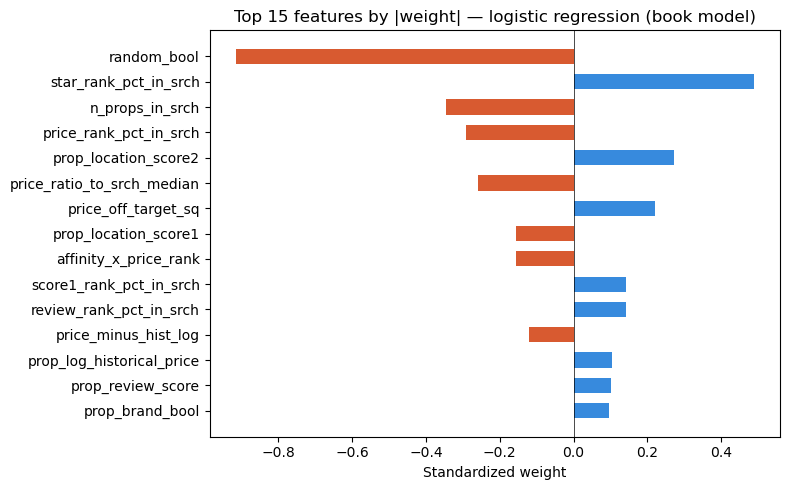

Saved: lr_weights.png


In [13]:
import matplotlib.pyplot as plt

weights = pd.Series(model_book.coef_[0], index=feature_cols).sort_values(key=np.abs, ascending=False)
print("Top 15 features by |weight| (book model):")
print(weights.head(15).to_string())

top = weights.head(15)[::-1]
colors = ["#378ADD" if w > 0 else "#D85A30" for w in top.values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.index, top.values, color=colors, height=0.6)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Standardized weight")
ax.set_title("Top 15 features by |weight| — logistic regression (book model)")
plt.tight_layout()
plt.savefig("lr_weights.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lr_weights.png")

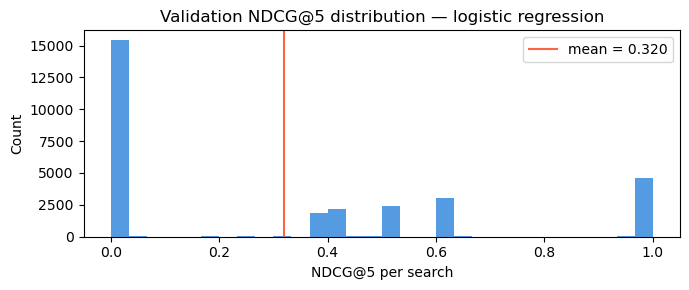

Saved: lr_ndcg_distribution.png


In [14]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(ndcg_per_query, bins=30, edgecolor="none", alpha=0.85, color="#378ADD")
ax.axvline(ndcg_per_query.mean(), color="tomato", linewidth=1.5,
           label=f"mean = {ndcg_per_query.mean():.3f}")
ax.set_xlabel("NDCG@5 per search")
ax.set_ylabel("Count")
ax.set_title("Validation NDCG@5 distribution — logistic regression")
ax.legend()
plt.tight_layout()
plt.savefig("lr_ndcg_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lr_ndcg_distribution.png")

## Section B': debias with Inverse Propensity Scoring

The largest learned weight in the baseline is on `random_bool`, which is Expedia's signal for "we showed these in random order". The model leaned heavily on it because position bias dominates the training labels: hotels shown at position 1 are clicked/booked far more than hotels at position 30, regardless of actual relevance.

IPS addresses this by reweighing each training sample by the inverse of its display propensity. Following the standard simple model:

- propensity(k) = 1 / k  where k is the displayed position
- IPS weight(k) = k, clipped at 10 to limit variance
- weights are normalized within each search so all searches contribute equally

In [15]:
%%time
if not TRAIN_RAW.is_file():
    raise FileNotFoundError(
        f"{TRAIN_RAW} not found. IPS needs the raw training CSV to read the position column."
    )

raw_cols = ["srch_id", "position", "click_bool", "booking_bool"]
raw = pd.read_csv(TRAIN_RAW, usecols=raw_cols)
print("raw shape:", raw.shape)

assert len(raw) == len(X_df), "raw and processed train have different row counts -- they must be the same order"
raw["split"] = X_df["split"].values
raw_train = raw[raw["split"] == "train"].reset_index(drop=True)
print("raw_train shape:", raw_train.shape)
print("position range:", raw_train["position"].min(), "->", raw_train["position"].max())

raw shape: (4958347, 4)
raw_train shape: (4214178, 5)
position range: 1 -> 40
CPU times: user 3.49 s, sys: 296 ms, total: 3.79 s
Wall time: 3.36 s


In [16]:
IPS_CLIP = 10.0

pos = raw_train["position"].clip(lower=1).astype(np.float32).values
raw_weights = np.minimum(pos, IPS_CLIP)

ips_df = pd.DataFrame({"srch_id": raw_train["srch_id"].values, "w": raw_weights})
grp_mean = ips_df.groupby("srch_id")["w"].transform("mean")
ips_weights = (raw_weights / grp_mean).astype(np.float32)

print(f"IPS weights: min={ips_weights.min():.3f}, mean={ips_weights.mean():.3f}, "
      f"max={ips_weights.max():.3f}")
print(f"fraction clipped at {IPS_CLIP}: {(pos >= IPS_CLIP).mean()*100:.2f}%")

IPS weights: min=0.107, mean=1.000, max=2.500
fraction clipped at 10.0: 68.31%


In [17]:
%%time
model_book_ips = LogisticRegression(C=1.0, class_weight=None, max_iter=300, solver="lbfgs", random_state=0, n_jobs=-1)
model_book_ips.fit(X_train_s, y_train_book, sample_weight=ips_weights)
p_val_book_ips = model_book_ips.predict_proba(X_val_s)[:, 1]
print("book LR (IPS) trained")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


book LR (IPS) trained
CPU times: user 47.5 s, sys: 13.4 s, total: 1min
Wall time: 7.04 s


In [18]:
%%time
model_click_ips = LogisticRegression(C=1.0, class_weight=None, max_iter=300, solver="lbfgs", random_state=0, n_jobs=-1)
model_click_ips.fit(X_train_s, y_train_click, sample_weight=ips_weights)
p_val_click_ips = model_click_ips.predict_proba(X_val_s)[:, 1]
print("click LR (IPS) trained")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


click LR (IPS) trained
CPU times: user 48.7 s, sys: 14.8 s, total: 1min 3s
Wall time: 8.14 s


In [19]:
p_val_ips = 4.0 * p_val_book_ips + 1.0 * p_val_click_ips
ndcg_ips, ndcg_per_query_ips = ndcg_at_5(y_val_rel, p_val_ips, srch_val, return_per_query=True)

print(f"  Baseline NDCG@5: {ndcg:.4f}")
print(f"  IPS NDCG@5:      {ndcg_ips:.4f}")
print(f"  delta:           {ndcg_ips - ndcg:+.4f}")

  Baseline NDCG@5: 0.3198
  IPS NDCG@5:      0.3142
  delta:           -0.0056


### Fairness evaluation: position-group NDCG@5

To check whether IPS actually reduces position-induced disparity (not just total NDCG), we compute NDCG@5 separately for queries grouped by where the booked/clicked hotel was originally displayed. If IPS is working, the gap between top-position and bottom-position groups should shrink, even if overall NDCG moves only slightly.

In [20]:
val_raw = raw[raw["split"] == "val"].reset_index(drop=True)
assert len(val_raw) == val_mask.sum(), "val raw vs val mask size mismatch"

target_pos = np.where(val_raw["booking_bool"] == 1, val_raw["position"],
                      np.where(val_raw["click_bool"] == 1, val_raw["position"], np.nan))
val_raw["target_pos"] = target_pos

def assign_group(p):
    if np.isnan(p):
        return None
    if p <= 3:
        return "A (pos 1-3)"
    if p <= 10:
        return "B (pos 4-10)"
    return "C (pos 11+)"

val_raw["group"] = val_raw["target_pos"].apply(assign_group)
print(val_raw["group"].value_counts(dropna=False).to_string())

group
None            711050
A (pos 1-3)      12970
B (pos 4-10)     10400
C (pos 11+)       9749


In [21]:
def ndcg_by_group(per_query_arr, groups_per_query):
    out = {}
    for g, scores in pd.DataFrame({"g": groups_per_query, "s": per_query_arr}).groupby("g", dropna=False):
        if pd.isna(g):
            continue
        out[g] = float(scores["s"].mean())
    out["Overall"] = float(per_query_arr.mean())
    return out

val_groups_per_query = val_raw.groupby("srch_id", sort=False)["group"].first().reindex(
    pd.unique(srch_val)
).values

scores_base = ndcg_by_group(ndcg_per_query, val_groups_per_query)
scores_ips_ = ndcg_by_group(ndcg_per_query_ips, val_groups_per_query)

print("NDCG@5 by position group:")
print(f"{'group':<14} {'baseline':>10} {'IPS':>10} {'delta':>10}")
for g in ["A (pos 1-3)", "B (pos 4-10)", "C (pos 11+)", "Overall"]:
    b = scores_base.get(g, float('nan'))
    i = scores_ips_.get(g, float('nan'))
    print(f"{g:<14} {b:>10.4f} {i:>10.4f} {i-b:>+10.4f}")

NDCG@5 by position group:
group            baseline        IPS      delta
A (pos 1-3)        0.4415     0.4243    -0.0173
B (pos 4-10)       0.2869     0.2872    +0.0004
C (pos 11+)        0.1835     0.1879    +0.0044
Overall            0.3198     0.3142    -0.0056


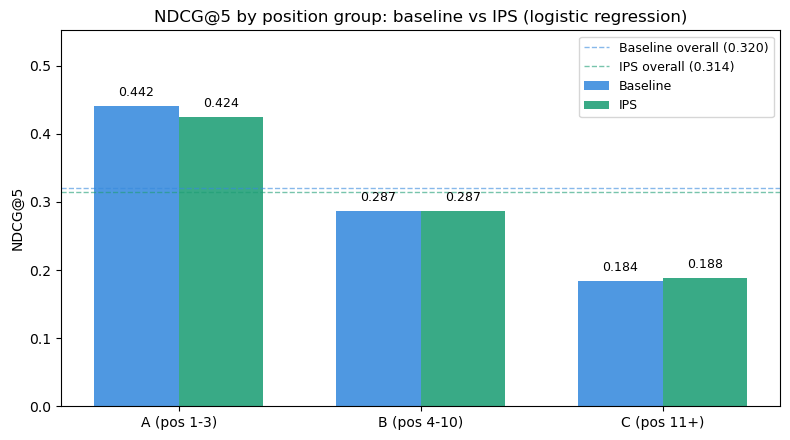

Saved: lr_ips_comparison.png


In [22]:
groups_plot = ["A (pos 1-3)", "B (pos 4-10)", "C (pos 11+)"]
x = np.arange(len(groups_plot))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
b1 = ax.bar(x - w/2, [scores_base[g] for g in groups_plot], w,
            label="Baseline", color="#378ADD", alpha=0.88)
b2 = ax.bar(x + w/2, [scores_ips_[g] for g in groups_plot], w,
            label="IPS",      color="#1D9E75", alpha=0.88)
ax.axhline(scores_base["Overall"], color="#378ADD", linestyle="--", linewidth=1.0, alpha=0.6,
           label=f"Baseline overall ({scores_base['Overall']:.3f})")
ax.axhline(scores_ips_["Overall"], color="#1D9E75", linestyle="--", linewidth=1.0, alpha=0.6,
           label=f"IPS overall ({scores_ips_['Overall']:.3f})")
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
            f"{h:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(groups_plot)
ax.set_ylabel("NDCG@5")
ax.set_title("NDCG@5 by position group: baseline vs IPS (logistic regression)")
ax.set_ylim(0, max(max(scores_base.values()), max(scores_ips_.values())) * 1.25)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("lr_ips_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lr_ips_comparison.png")

## Section C: make predictions

Same interaction features, same scaler, then for each search we sort the candidate hotels by predicted score (highest first).

In [23]:
if not TEST_X.is_file():
    raise FileNotFoundError(f"{TEST_X} not found. Run Section B first.")
test_df = pd.read_csv(TEST_X)
print("loaded test_X_full:", test_df.shape)
test_df = add_interactions(test_df)
missing = [c for c in feature_cols if c not in test_df.columns]
assert not missing, f"missing in test: {missing}"
X_test = test_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).astype(np.float32).values
X_test_s = scaler.transform(X_test)
print("X_test_s shape:", X_test_s.shape)

loaded test_X_full: (4959183, 64)
X_test_s shape: (4959183, 70)


In [24]:
%%time
def build_submission(p_book, p_click, out_path, label):
    score = 4.0 * p_book + 1.0 * p_click
    s = pd.DataFrame({
        "srch_id": test_df["srch_id"].values,
        "prop_id": test_df["prop_id"].values,
        "score": score,
    })
    s = s.sort_values(["srch_id", "score"], ascending=[True, False])
    s = s.drop(columns=["score"]).rename(columns={"srch_id": "SearchId", "prop_id": "PropertyId"})
    s.to_csv(out_path, index=False)
    print(f"  {label:20s} val NDCG@5={ndcg if label == 'baseline' else ndcg_ips:.4f}  ->  {out_path.name} ({len(s):,} rows)")
    return s

# baseline submission
p_test_book_base = model_book.predict_proba(X_test_s)[:, 1]
p_test_click_base = model_click.predict_proba(X_test_s)[:, 1]
sub_base = build_submission(p_test_book_base, p_test_click_base, SUBMISSION, "baseline")

# debiased (IPS) submission
p_test_book_ips_ = model_book_ips.predict_proba(X_test_s)[:, 1]
p_test_click_ips_ = model_click_ips.predict_proba(X_test_s)[:, 1]
sub_ips = build_submission(p_test_book_ips_, p_test_click_ips_, SUBMISSION_IPS, "IPS (debiased)")

print()

  baseline             val NDCG@5=0.3198  ->  submission_lr.csv (4,959,183 rows)
  IPS (debiased)       val NDCG@5=0.3142  ->  submission_lr_debiased.csv (4,959,183 rows)

CPU times: user 11.5 s, sys: 9.51 s, total: 21 s
Wall time: 10.4 s
